# 04 — Recommendation Experiments

**Phase 3B.** Baselines first, hybrid last — as CLAUDE.md §13 requires and as [R26]
argues is the only way a comparison means anything.

This notebook is an **explorable view** of the experiments, not their implementation.
Everything shown comes from `scripts/run_recommendation_experiments.py` and the
`edupro.recommendation` / `edupro.evaluation` packages (§19).

## The protocol, pre-registered in Phase 1

| Window | Range | Role |
|---|---|---|
| Training | < 2025-09-12 | features, popularity, similarity |
| Validation | 2025-09-12 → 2025-10-18 | **all model selection** |
| Fit | < 2025-10-18 | final training |
| Test | ≥ 2025-10-18 | **touched exactly once** |

In [1]:
import json

import pandas as pd
from IPython.display import Image, display

from edupro import config

REC = config.ARTIFACTS_DIR / "recommendation"
results = json.loads((REC / "recommendation_results.json").read_text(encoding="utf-8"))
K = "10"
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

p = results["provenance"]
print(f"validation cut : {p['validation_cut']}")
print(f"test cut       : {p['test_cut']}")
print(f"seed           : {p['seed']}")
print(f"segmentation   : {p['segmentation']}")
print(f"\nvalidation set : {results['validation_set']}")
print(f"test set       : {results['test_set']}")

validation cut : 2025-09-12
test cut       : 2025-10-18
seed           : 42
segmentation   : {'representation': 'B_proportion', 'k': 4}

validation set : {'protocol': 'A_validation', 'n_users': 511, 'n_held_out_interactions': 788, 'mean_held_out_per_user': 1.5421, 'users_by_tier': {'rich': 231, 'minimal': 102, 'moderate': 178}}
test set       : {'protocol': 'A_test', 'n_users': 791, 'n_held_out_interactions': 1625, 'mean_held_out_per_user': 2.0544, 'users_by_tier': {'moderate': 193, 'rich': 385, 'minimal': 213}}


## Step 1 — Leakage checks

Run as part of the experiment, not as a separate review. Leakage produces
plausible-looking numbers, so it cannot be caught by inspection.

In [2]:
for stage in ("leakage_validation", "leakage_test"):
    print(f"\n{stage}:")
    for check, payload in results[stage].items():
        if isinstance(payload, dict):
            print(f"  {'PASS' if payload['passed'] else 'FAIL'}  {check}")
    print(f"  -> all passed: {results[stage]['all_passed']}")


leakage_validation:
  PASS  L1_no_heldout_rows_in_training
  PASS  L1b_training_strictly_before_cut
  PASS  L2_exclusion_from_training_history_only
  PASS  L3_tier_from_training_history_only
  PASS  L5_popularity_from_training_only
  PASS  L6_heldout_items_in_candidate_pool
  -> all passed: True

leakage_test:
  PASS  L1_no_heldout_rows_in_training
  PASS  L1b_training_strictly_before_cut
  PASS  L2_exclusion_from_training_history_only
  PASS  L3_tier_from_training_history_only
  PASS  L5_popularity_from_training_only
  PASS  L6_heldout_items_in_candidate_pool
  -> all passed: True


## Steps 2–6 — Baselines on the validation split

Model selection happens here and only here. Ten methods, each given the same
treatment.

In [3]:
def table(stage: str) -> pd.DataFrame:
    rows = []
    for method, payload in results[stage].items():
        rows.append({"method": method, **payload["overall"][K]})
    frame = pd.DataFrame(rows).sort_values("ndcg", ascending=False)
    return frame[[
        "method", "ndcg", "hit_rate", "precision", "precision_ceiling",
        "precision_vs_ceiling", "recall", "mrr", "coverage", "gini",
    ]].reset_index(drop=True)

display(table("validation"))

,method,ndcg,hit_rate,precision,precision_ceiling,precision_vs_ceiling,recall,mrr,coverage,gini
0,hybrid,0.114834,0.336595,0.035616,0.154207,0.230964,0.236611,0.120040,0.800000,0.657058
1,tiered,0.113516,0.332681,0.035225,0.154207,0.228426,0.234654,0.118856,1.000000,0.607736
2,cluster_popularity,0.109768,0.303327,0.032290,0.154207,0.209391,0.213780,0.123378,0.783333,0.605936
3,item_item_cf,0.106661,0.297456,0.032290,0.154207,0.209391,0.212052,0.118650,1.000000,0.468343
4,user_user_history,0.106516,0.277886,0.029354,0.154207,0.190355,0.200473,0.123726,1.000000,0.141631
5,global_popularity,0.105407,0.287671,0.031311,0.154207,0.203046,0.213862,0.116539,0.300000,0.807345
6,teacher_affinity,0.104306,0.277886,0.029941,0.154207,0.194162,0.194879,0.121689,1.000000,0.665558
7,content_based,0.103493,0.287671,0.030724,0.154207,0.199239,0.210616,0.116757,1.000000,0.529511
8,random,0.097259,0.260274,0.028376,0.154207,0.184010,0.189139,0.113771,1.000000,0.054860
9,rating,0.095628,0.260274,0.028767,0.154207,0.186548,0.185339,0.114098,0.300000,0.810920


## Step 7 — Hybrid: weight search and ablation

Weights are **searched on the validation split**, never chosen by hand (§14).

samples: 400  best validation NDCG@10: 0.114834
NDCG spread across the whole search: {'min': 0.083238, 'max': 0.114834, 'std': 0.00567}

best weights:
  cluster_popularity     0.5574
  rating                 0.2488
  item_item_cf           0.1732
  preference_match       0.0205
  content_based          0.0000
  user_user_profile      0.0000

component ablation:


,removed,weight_in_best,ndcg,delta_vs_full,coverage
0,content_based,0.0000,0.114834,0.000000,0.800000
1,user_user_profile,0.0000,0.114834,0.000000,0.800000
2,cluster_popularity,0.5574,0.106021,-0.008813,0.533333
3,rating,0.2488,0.104677,-0.010157,0.966667
4,preference_match,0.0205,0.115072,0.000238,0.800000
5,item_item_cf,0.1732,0.111215,-0.003619,0.683333


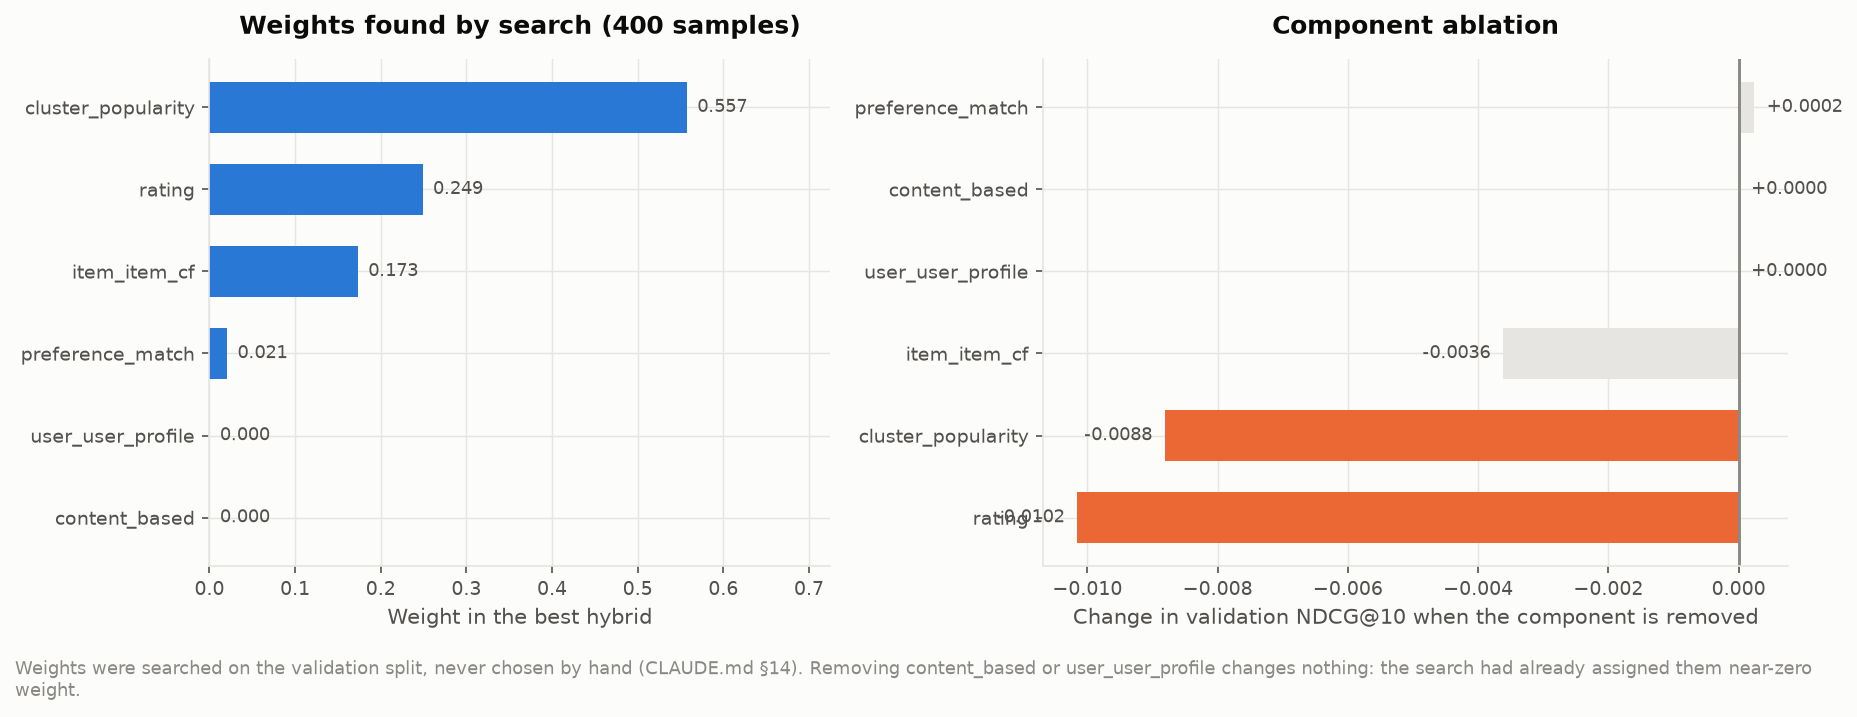

In [4]:
search = results["EXP-024_weight_search"]
print(f"samples: {search['n_samples']}  best validation NDCG@10: {search['best_validation_ndcg']}")
print(f"NDCG spread across the whole search: {search['ndcg_spread']}")
print("\nbest weights:")
for name, weight in sorted(search["best_weights"].items(), key=lambda kv: -kv[1]):
    print(f"  {name:<22} {weight:.4f}")
print("\ncomponent ablation:")
display(pd.DataFrame(results["EXP-024b_ablation"]))
display(Image(filename=str(REC / "05_weights_and_ablation.png")))

## The pre-registered selection

Eligibility → coverage gate → rank by validation NDCG@10 → **parsimony tiebreak**.

In [5]:
selection = results["selection"]
print(f"random NDCG@10     : {selection['random_ndcg']:.4f}")
print(f"popularity NDCG@10 : {selection['popularity_ndcg']:.4f}")
display(pd.DataFrame(selection["candidates"]))
print(f"\nSELECTED: {selection['selected']}")
print(f"REASON  : {selection['reason']}")

random NDCG@10     : 0.0973
popularity NDCG@10 : 0.1054


,method,validation_ndcg,coverage,beats_random,beats_popularity,passes_coverage_gate,eligible,complexity
0,hybrid,0.114834,0.800000,True,True,True,True,6
1,tiered,0.113516,1.000000,True,True,True,True,7
2,cluster_popularity,0.109768,0.783333,True,True,True,True,3
3,item_item_cf,0.106661,1.000000,True,True,True,True,3
4,user_user_history,0.106516,1.000000,True,True,True,True,3
5,global_popularity,0.105407,0.300000,True,False,True,False,1
6,teacher_affinity,0.104306,1.000000,True,False,True,False,2
7,content_based,0.103493,1.000000,True,False,True,False,2
8,rating,0.095628,0.300000,False,False,True,False,1
9,user_user_profile,0.094403,1.000000,False,False,True,False,4



SELECTED: cluster_popularity
REASON  : parsimony tiebreak: the best method beat the simplest eligible one by 0.0051 NDCG@10, under the pre-registered 0.01 margin


## The test window — evaluated once

791 evaluable learners, leakage-free.

,method,ndcg,hit_rate,precision,precision_ceiling,precision_vs_ceiling,recall,mrr,coverage,gini,engagement_lift_proxy
0,hybrid,0.120647,0.357775,0.043489,0.205436,0.211692,0.210124,0.151128,0.916667,0.631193,1.080153
1,content_based,0.119113,0.366625,0.043869,0.205436,0.213538,0.220453,0.142728,1.000000,0.498230,1.106872
2,preference_match,0.116497,0.365360,0.041593,0.205436,0.202462,0.211205,0.145440,1.000000,0.464513,1.103053
3,cluster_popularity,0.113773,0.359039,0.042351,0.205436,0.206154,0.207974,0.141154,0.750000,0.572992,1.083969
4,tiered,0.111665,0.345133,0.042478,0.205436,0.206769,0.199800,0.142339,1.000000,0.551302,1.041986
5,user_user_profile,0.110519,0.347661,0.041087,0.205436,0.200000,0.201025,0.139720,1.000000,0.267425,1.049618
6,random,0.110215,0.346397,0.042225,0.205436,0.205538,0.197542,0.143995,1.000000,0.049482,1.045802
7,teacher_affinity,0.107592,0.352718,0.040961,0.205436,0.199385,0.201848,0.134996,1.000000,0.625942,1.064885
8,global_popularity,0.107216,0.331226,0.038938,0.205436,0.189538,0.187277,0.143952,0.316667,0.806903,0.999999
9,item_item_cf,0.104663,0.351454,0.041972,0.205436,0.204308,0.206898,0.125284,1.000000,0.477889,1.061069


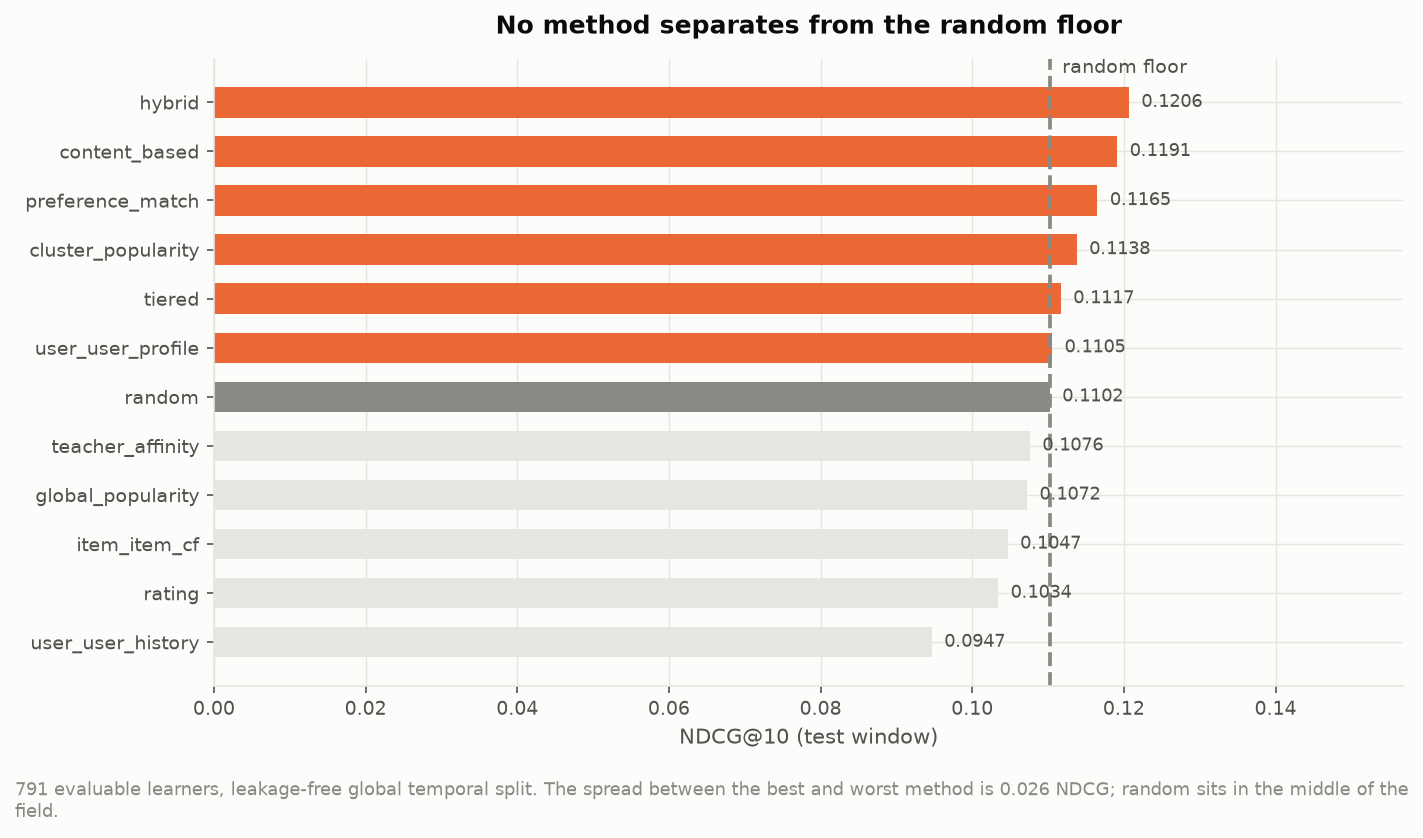

In [6]:
test = table("test")
test["engagement_lift_proxy"] = [
    results["test"][m]["engagement_lift_proxy"] for m in test.method
]
display(test)
display(Image(filename=str(REC / "01_method_comparison.png")))

## The decisive question: does anything beat random?

An aggregate gap of a few thousandths of NDCG on 791 learners means nothing
without a paired test. Pairing by learner removes the between-learner variance
that dominates here, where one learner has five held-out courses and another one.

,method,n_users,mean_difference,ci_95_low,ci_95_high,significant,direction
0,hybrid,791,0.016219,-0.003336,0.035485,False,better
1,content_based,791,0.014686,-0.004034,0.033975,False,better
2,preference_match,791,0.012070,-0.006826,0.030542,False,better
3,cluster_popularity,791,0.009345,-0.009186,0.027055,False,better
4,tiered,791,0.007238,-0.012647,0.024546,False,better
5,user_user_profile,791,0.006092,-0.011310,0.025069,False,better
6,teacher_affinity,791,0.003164,-0.014992,0.020878,False,better
7,global_popularity,791,0.002789,-0.015458,0.020532,False,better
8,item_item_cf,791,0.000235,-0.017868,0.017408,False,better
9,rating,791,-0.001023,-0.019290,0.016292,False,worse


methods significantly better than random: 0


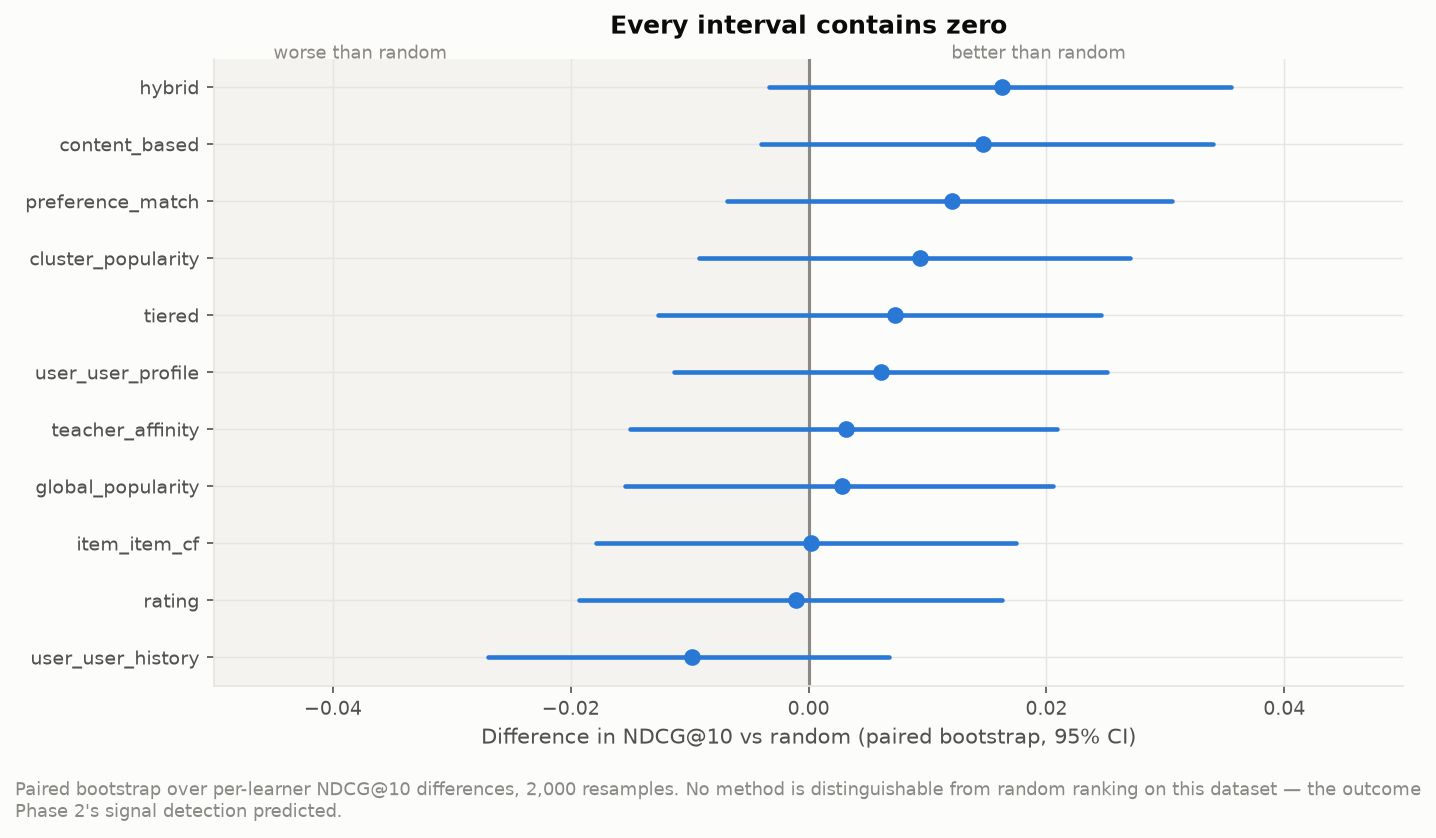

In [7]:
rows = []
for method, payload in results["significance_vs_random"]["per_method"].items():
    rows.append({"method": method, **payload["vs_random"]})
display(pd.DataFrame(rows).sort_values("mean_difference", ascending=False).reset_index(drop=True))
print(f"methods significantly better than random: "
      f"{results['significance_vs_random']['n_methods_significantly_better_than_random']}")
display(Image(filename=str(REC / "02_significance_vs_random.png")))

## Step 9 — Coverage

Both senses: how many learners get a recommendation, and how much of the
catalogue ever gets recommended.

  total_learners: 3000
  learners_with_training_history: 2650
  learners_receiving_recommendations: 3000
  learners_receiving_personalised: 2650
  learners_on_fallback: 350
  learners_by_tier: {'minimal': 1514, 'moderate': 731, 'rich': 405, 'insufficient': 350}
  mean_candidate_pool: 57.43
  learners_with_empty_candidate_pool: 0


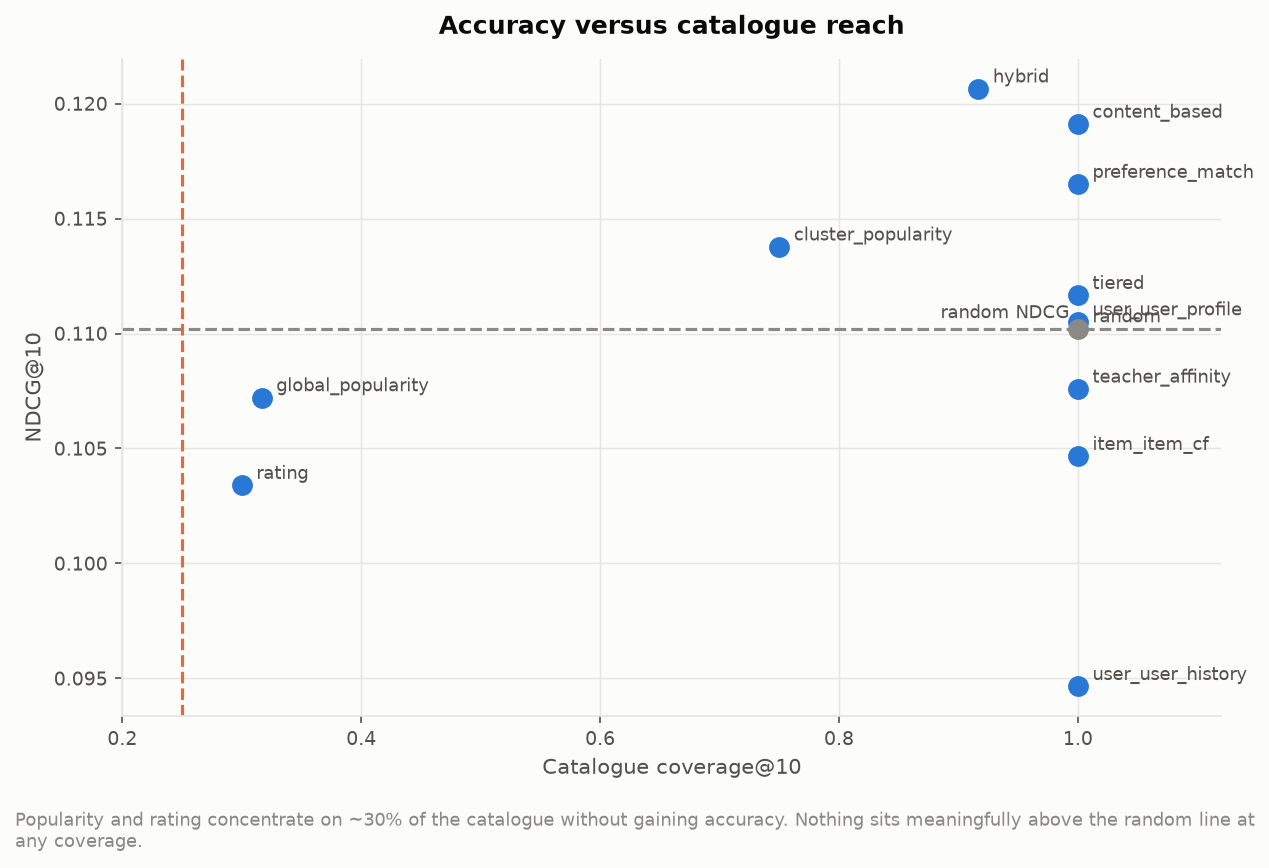

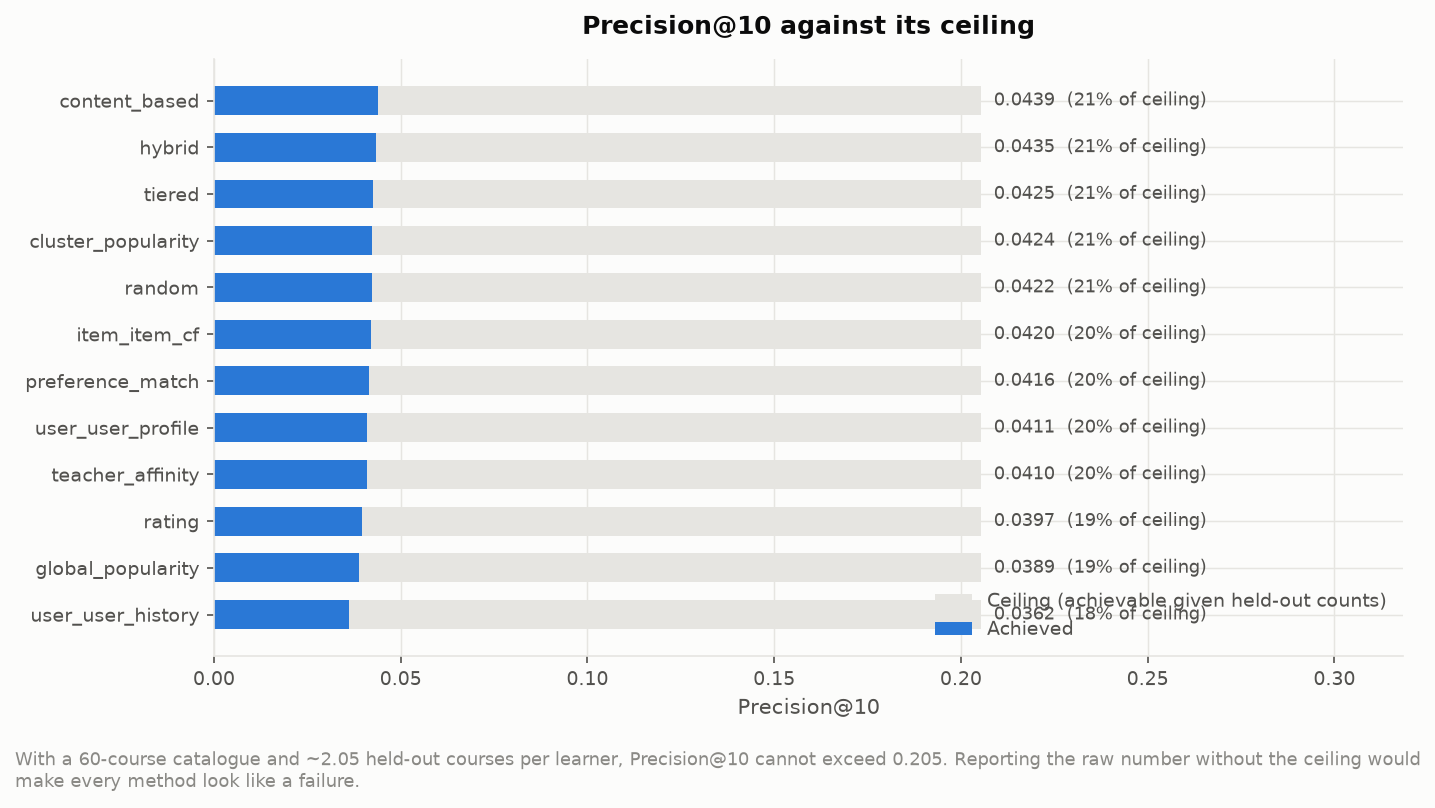

In [8]:
for key, value in results["EXP-009_coverage_accounting"].items():
    print(f"  {key}: {value}")
display(Image(filename=str(REC / "03_accuracy_vs_coverage.png")))
display(Image(filename=str(REC / "08_precision_ceiling.png")))

## Step 8 — Sparse-user behaviour

Per tier, and paired against random within each tier.

per-tier, reported method vs random:


,n_users,mean_difference,ci_95_low,ci_95_high,significant,direction
minimal,213,0.030673,-0.007626,0.068672,False,better
moderate,193,-0.011218,-0.046319,0.022885,False,worse
rich,385,0.007854,-0.016464,0.034185,False,better



hit rate by number of held-out courses — the arithmetic confound:


,n,hit_rate
1,405.0,0.207407
2,155.0,0.380645
3,103.0,0.572816
4,65.0,0.569231
5,44.0,0.659091
6,13.0,0.846154


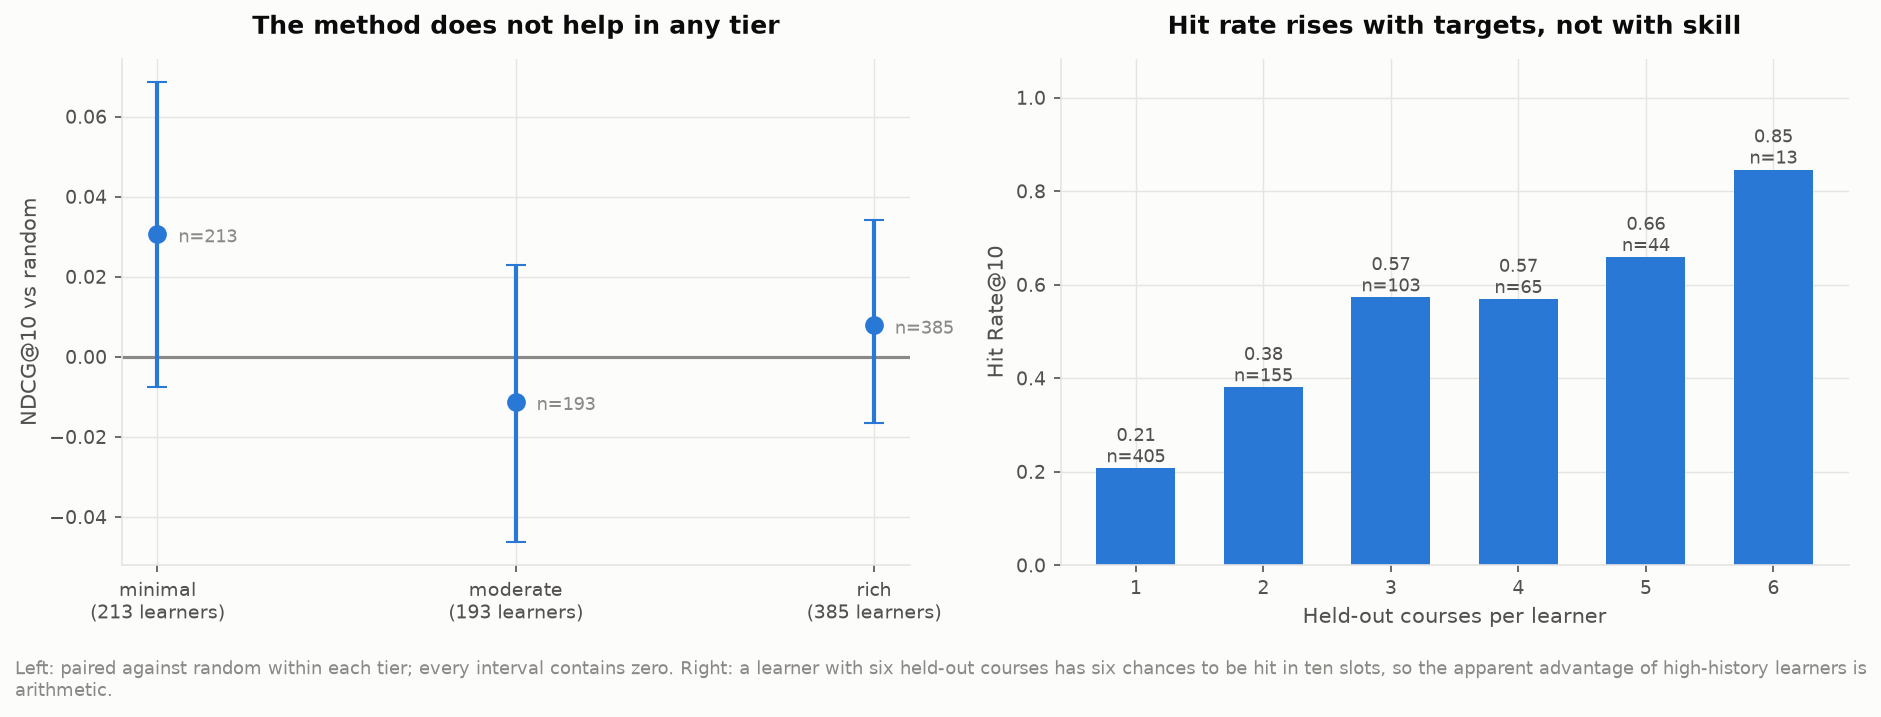

In [9]:
print("per-tier, reported method vs random:")
display(pd.DataFrame(results["per_tier_significance_vs_random"]["per_tier"]).T)
print("\nhit rate by number of held-out courses — the arithmetic confound:")
display(pd.DataFrame(results["EXP-error_analysis"]["by_n_targets"]).T)
display(Image(filename=str(REC / "04_tier_behaviour.png")))

## Step 11 — Error analysis

method: cluster_popularity   overall HR@10: 0.3590

category_match:
  when_history_category_overlaps_target: 0.44289
  when_it_does_not: 0.259669
  n_overlapping: 429

level_match:
  when_history_level_overlaps_target: 0.455717
  when_it_does_not: 0.005882
  n_overlapping: 621

popularity_bias:
  mean_recommended_popularity_rank: 16.76
  mean_target_popularity_rank: 28.56
  catalogue_midpoint: 30.0
  hits_mean_target_rank: 23.31
  misses_mean_target_rank: 31.5

candidate_pool:
  mean: 53.48
  min: 45
  max: 59
  users_with_pool_below_k: 0


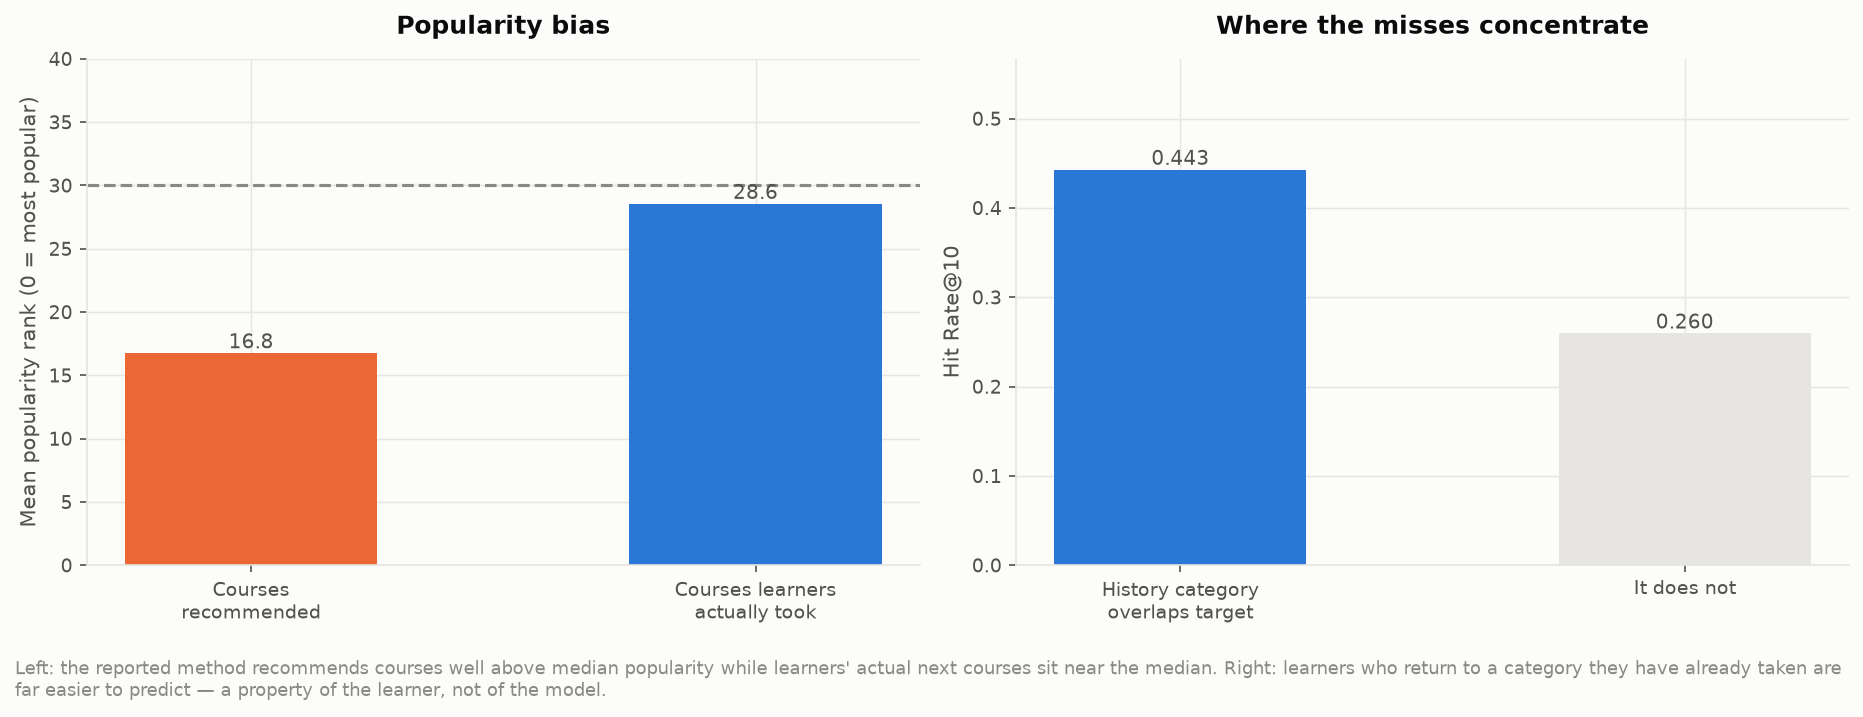

In [10]:
analysis = results["EXP-error_analysis"]
print(f"method: {analysis['method']}   overall HR@10: {analysis['overall_hit_rate']:.4f}")
for section in ("category_match", "level_match", "popularity_bias", "candidate_pool"):
    print(f"\n{section}:")
    for key, value in analysis[section].items():
        print(f"  {key}: {value}")
display(Image(filename=str(REC / "07_error_analysis.png")))

## EXP-026 — The protocol reorders the methods

Protocol B leaks by the global-timeline definition [R25]. It is reported only for
comparability with published work.

PROTOCOL B LEAKS. Each learner's cut is a different calendar date, so training contains interactions occurring after some learners' test points [R25]. Reported only for comparability with published work.


,method,protocol_a_ndcg,protocol_b_ndcg,inflation
0,random,0.110215,0.078526,-0.031689
1,global_popularity,0.107216,0.087644,-0.019572
2,rating,0.103404,0.077264,-0.026140
3,content_based,0.119113,0.089943,-0.029170
4,preference_match,0.116497,0.087042,-0.029455
5,user_user_history,0.094655,0.080531,-0.014124
6,user_user_profile,0.110519,0.086396,-0.024123
7,item_item_cf,0.104663,0.089347,-0.015316
8,cluster_popularity,0.113773,0.085027,-0.028746
9,teacher_affinity,0.107592,0.079851,-0.027741



rankings agree: False


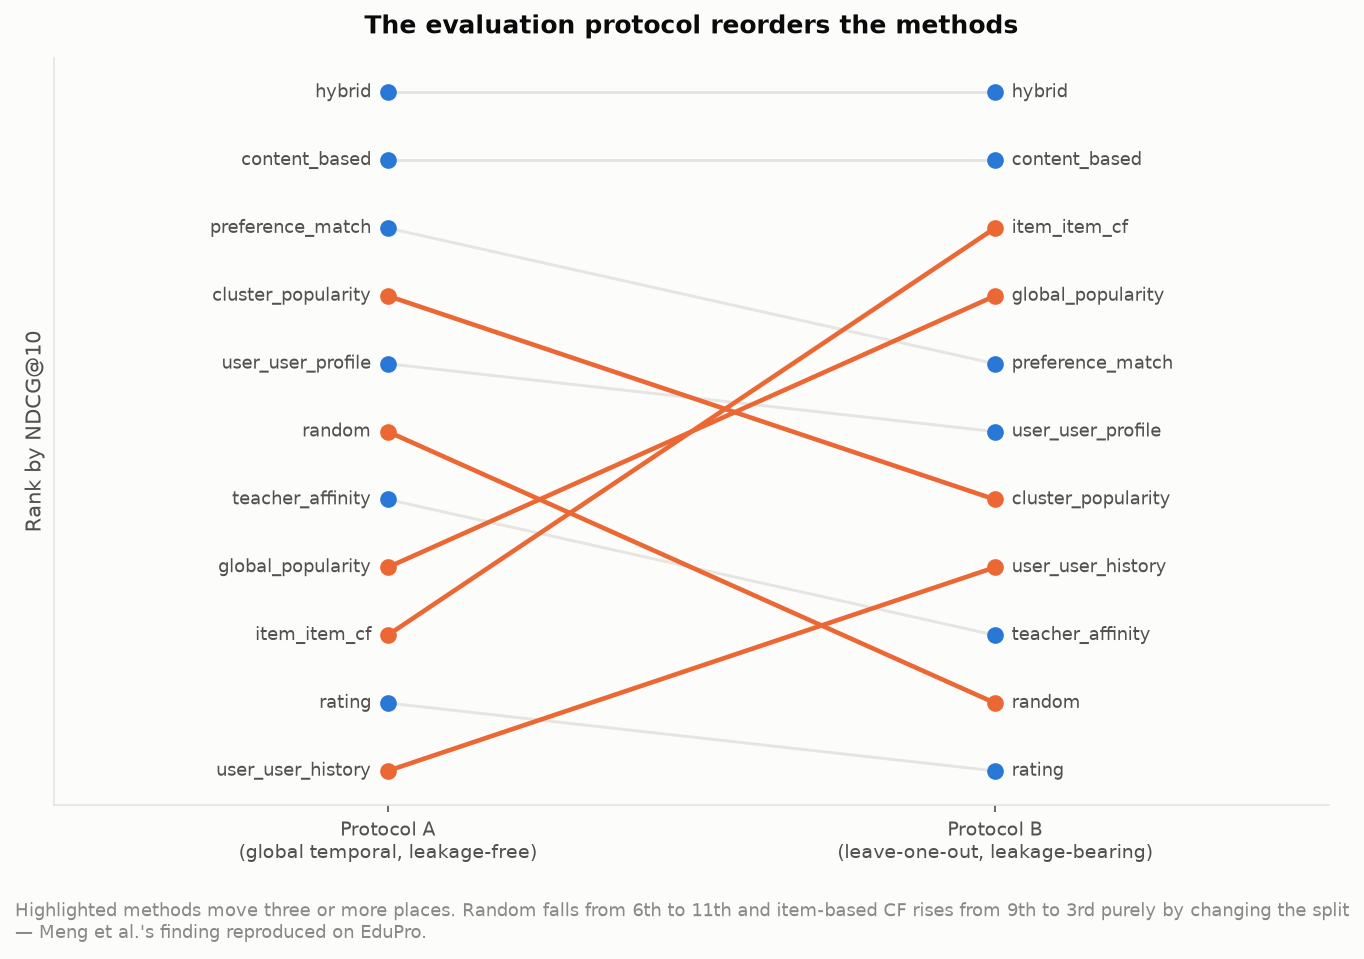

In [11]:
protocol_b = results["EXP-026_protocol_b"]
print(protocol_b["warning"])
display(pd.DataFrame(protocol_b["comparison"]))
print(f"\nrankings agree: {protocol_b['rankings_agree']}")
display(Image(filename=str(REC / "06_protocol_comparison.png")))

## EXP-027 — Demographic-stratified evaluation

Run even though the recommender uses no demographic feature. Being able to report
whether quality is equivalent across groups is a stronger position than not
looking [R30].

In [12]:
strata = results["EXP-027_demographic_strata"]
display(pd.DataFrame(strata["strata"]).T)
gap = strata["gender_gap_test"]
print(f"gender gap (female - male) : {gap['difference']:+.4f} "
      f"[{gap['ci_95_low']:+.4f}, {gap['ci_95_high']:+.4f}]")
print(f"nominally significant      : {gap['significant']}")
print(f"consistent across tiers    : {gap['consistent_direction_across_tiers']}")
display(pd.DataFrame(gap["within_tier"]).T)

,n_users,ndcg,hit_rate,coverage
female,412.0,0.100219,0.339806,0.750000
male,379.0,0.128507,0.379947,0.733333
age_15_24,374.0,0.119760,0.371658,0.750000
age_25_35,417.0,0.108403,0.347722,0.733333


gender gap (female - male) : -0.0283 [-0.0543, -0.0010]
nominally significant      : True
consistent across tiers    : True


,n_female,n_male,female_ndcg,male_ndcg,difference
minimal,119.0,94.0,0.096774,0.114402,-0.017628
moderate,102.0,91.0,0.086835,0.111752,-0.024916
rich,191.0,194.0,0.109512,0.143201,-0.033689


## Conclusions

1. **No method beats random.** Every 95% interval on the paired NDCG@10 difference
   contains zero, in aggregate and within every history tier.
2. **Global popularity is *worse* than random on the test window** (0.1072 vs
   0.1102) — consistent with Phase 2's finding that course popularity is
   near-uniform (Gini 0.042).
3. **The pre-registered parsimony tiebreak selected `cluster_popularity`** over the
   hybrid, which beat it by only 0.0051 validation NDCG@10.
4. **Hit rate rises with the number of held-out courses, not with skill** — a
   learner with six targets has six chances in ten slots.
5. **The evaluation protocol reorders the methods**, reproducing Meng et al. on
   EduPro: random moves from 6th to 11th between protocols.

Full write-up: `research/recommendation_results.md` and
`research/recommendation_error_analysis.md`.